In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving country_wise_latest.csv to country_wise_latest.csv


In [3]:
df = pd.read_csv('country_wise_latest.csv')
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [4]:
df.shape

(187, 15)

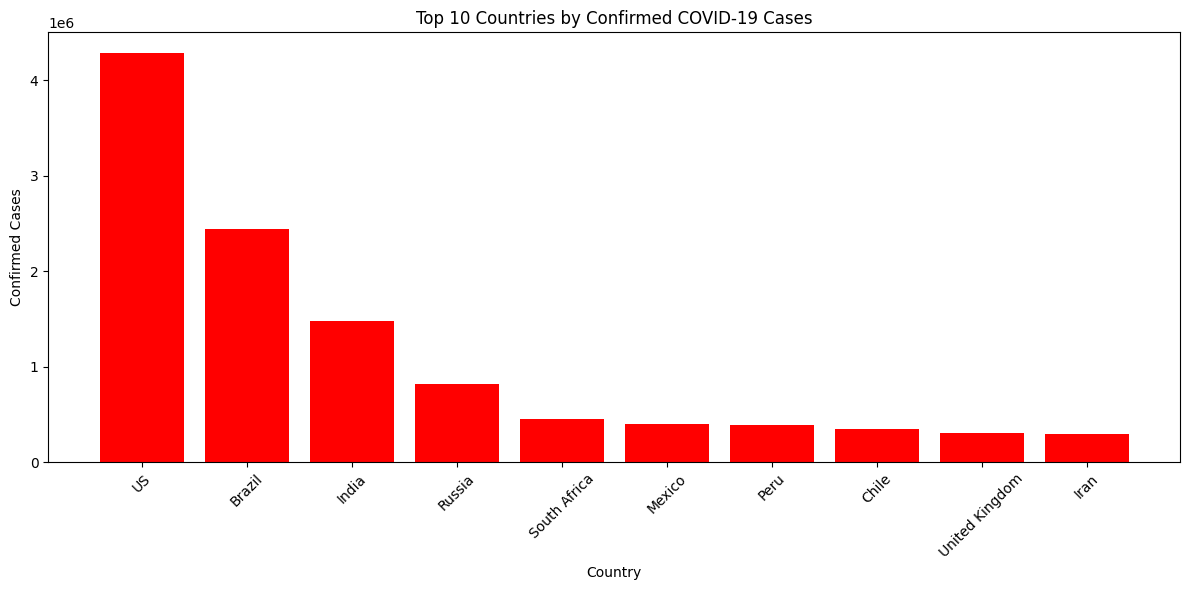

In [5]:
# Top 10 countries by confirmed cases
top10 = df.nlargest(10, 'Confirmed')
plt.figure(figsize=(12,6))
plt.bar(top10['Country/Region'], top10['Confirmed'], color='red')
plt.title('Top 10 Countries by Confirmed COVID-19 Cases')
plt.xlabel('Country')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

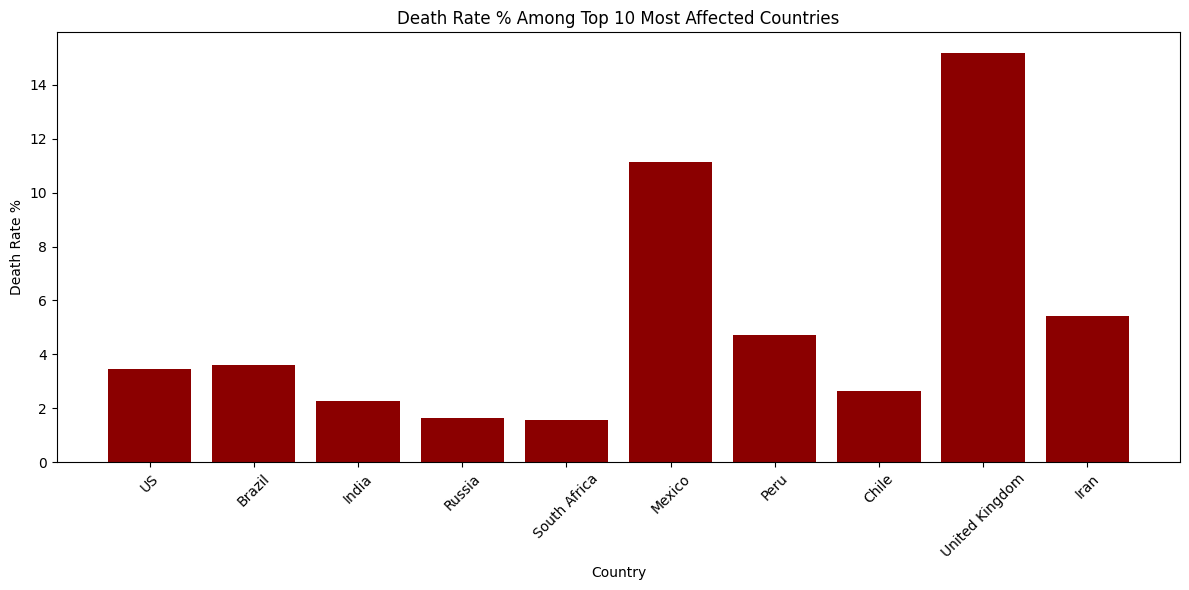

In [6]:
# Death rate by country - top 10
top10['Death_Rate'] = (top10['Deaths'] / top10['Confirmed']) * 100
plt.figure(figsize=(12,6))
plt.bar(top10['Country/Region'], top10['Death_Rate'], color='darkred')
plt.title('Death Rate % Among Top 10 Most Affected Countries')
plt.xlabel('Country')
plt.ylabel('Death Rate %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

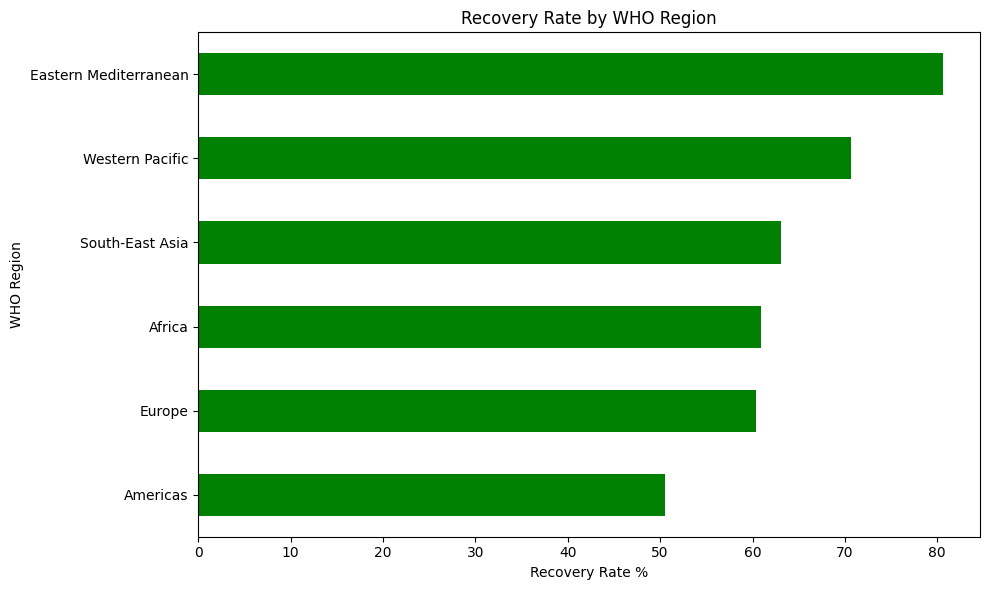

In [7]:
# Recovery rate by WHO Region
region = df.groupby('WHO Region')[['Confirmed', 'Recovered', 'Deaths']].sum()
region['Recovery_Rate'] = (region['Recovered'] / region['Confirmed']) * 100
region['Recovery_Rate'].sort_values().plot(kind='barh', color='green', figsize=(10,6))
plt.title('Recovery Rate by WHO Region')
plt.xlabel('Recovery Rate %')
plt.tight_layout()
plt.show()

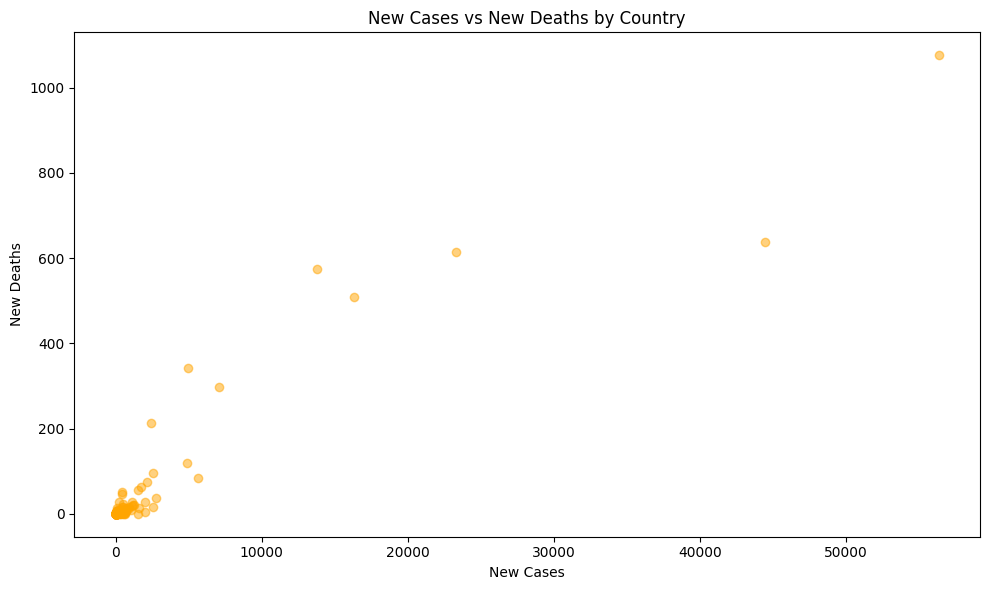

In [8]:
# New cases vs Deaths scatter plot
plt.figure(figsize=(10,6))
plt.scatter(df['New cases'], df['New deaths'], alpha=0.5, color='orange')
plt.title('New Cases vs New Deaths by Country')
plt.xlabel('New Cases')
plt.ylabel('New Deaths')
plt.tight_layout()
plt.show()

In [9]:
print("=== COVID-19 Global Analysis - Key Findings ===")
print(f"Total Countries Analysed: {df.shape[0]}")
print(f"Most Confirmed Cases: {df.loc[df['Confirmed'].idxmax(), 'Country/Region']} with {df['Confirmed'].max():,} cases")
print(f"Highest Death Rate (Top 10): {top10.loc[top10['Death_Rate'].idxmax(), 'Country/Region']} at {top10['Death_Rate'].max():.2f}%")
print(f"Best Recovery Rate Region: {region['Recovery_Rate'].idxmax()} at {region['Recovery_Rate'].max():.2f}%")
print(f"Total Global Confirmed Cases: {df['Confirmed'].sum():,}")
print(f"Total Global Deaths: {df['Deaths'].sum():,}")
print(f"Overall Global Death Rate: {(df['Deaths'].sum()/df['Confirmed'].sum()*100):.2f}%")

=== COVID-19 Global Analysis - Key Findings ===
Total Countries Analysed: 187
Most Confirmed Cases: US with 4,290,259 cases
Highest Death Rate (Top 10): United Kingdom at 15.19%
Best Recovery Rate Region: Eastern Mediterranean at 80.59%
Total Global Confirmed Cases: 16,480,485
Total Global Deaths: 654,036
Overall Global Death Rate: 3.97%
